In [3]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os

In [4]:
#chargement des donnees d une base sur les valve 
BASE_PATH = r"C:\soundsense\data\mimii\valve\valve"
MACHINE_ID = "id_00"

normal_path = os.path.join(BASE_PATH, MACHINE_ID, "normal")
abnormal_path = os.path.join(BASE_PATH, MACHINE_ID, "abnormal")

normal_files = [os.path.join(normal_path, f) for f in os.listdir(normal_path)]
abnormal_files = [os.path.join(abnormal_path, f) for f in os.listdir(abnormal_path)]

print(f"Normal files: {len(normal_files)}")
print(f"Abnormal files: {len(abnormal_files)}")

Normal files: 991
Abnormal files: 119


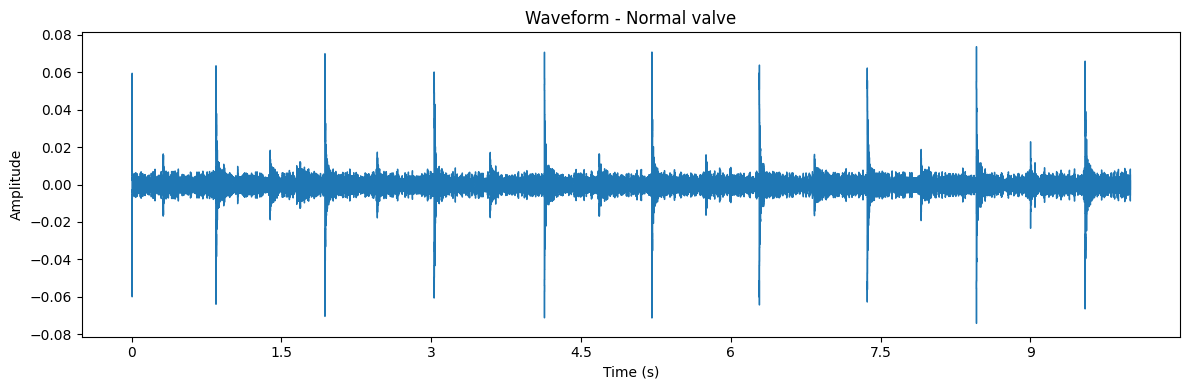

In [6]:
# visu onde valve normal 
audio, sr = librosa.load(normal_files[0], sr=None)

plt.figure(figsize=(12, 4))
librosa.display.waveshow(audio, sr=sr)
plt.title("Waveform - Normal valve")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

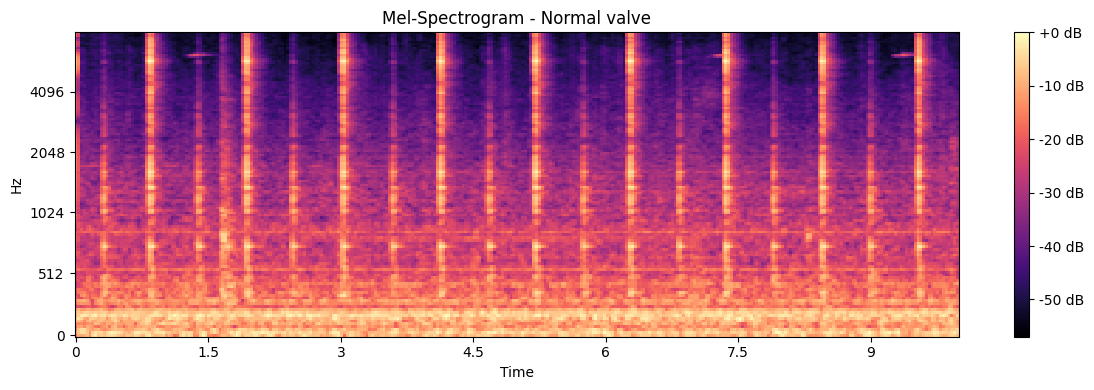

In [7]:
# visu Mel-Spectrogram normal
mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

plt.figure(figsize=(12, 4))
librosa.display.specshow(mel_spec_db, sr=sr, x_axis="time", y_axis="mel")
plt.colorbar(format="%+2.0f dB")
plt.title("Mel-Spectrogram - Normal valve")
plt.tight_layout()
plt.show()

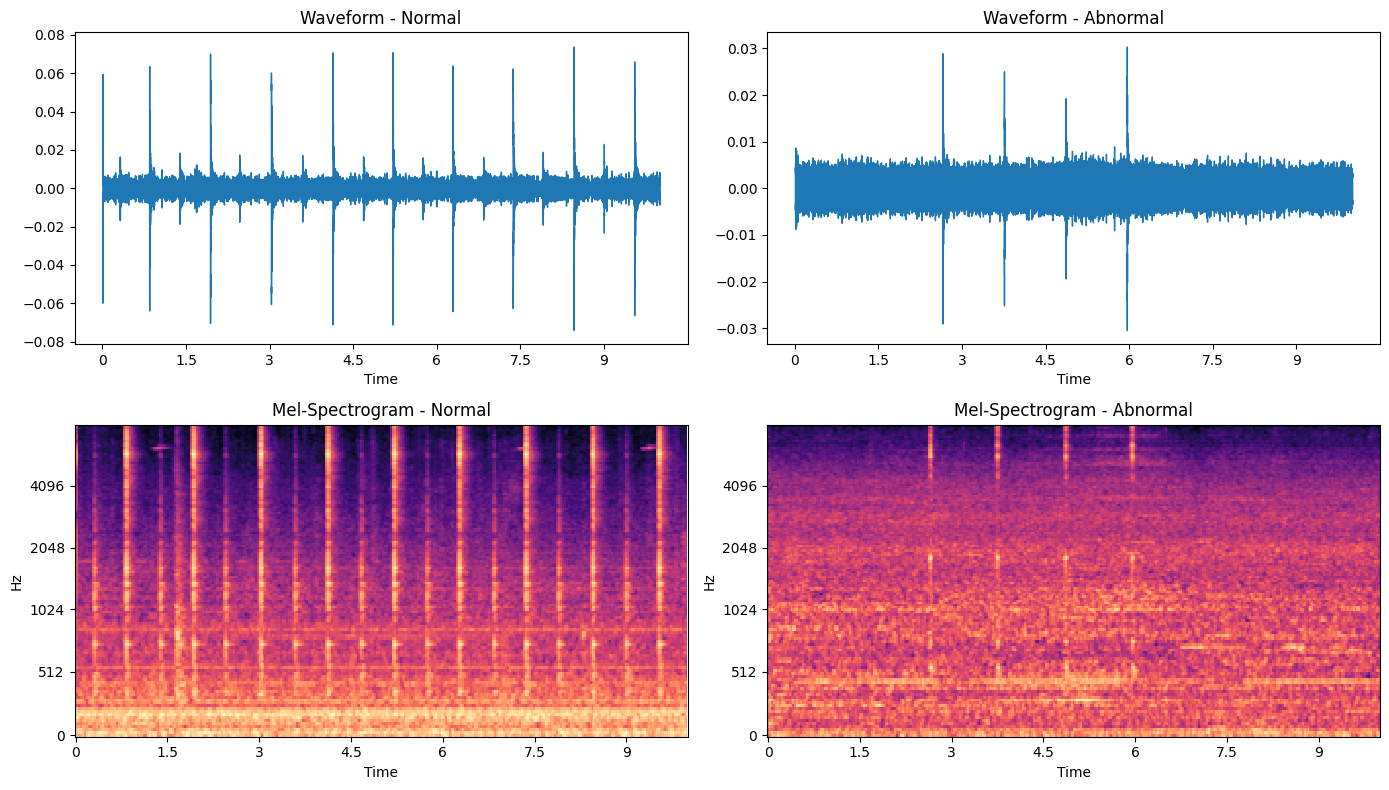

In [8]:
#Comparaison Normal vs Abnormal
audio_normal, sr = librosa.load(normal_files[0], sr=None)
audio_abnormal, _ = librosa.load(abnormal_files[0], sr=None)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Waveforms
librosa.display.waveshow(audio_normal, sr=sr, ax=axes[0, 0])
axes[0, 0].set_title("Waveform - Normal")

librosa.display.waveshow(audio_abnormal, sr=sr, ax=axes[0, 1])
axes[0, 1].set_title("Waveform - Abnormal")

# Mel-spectrograms
mel_normal = librosa.power_to_db(librosa.feature.melspectrogram(y=audio_normal, sr=sr, n_mels=128), ref=np.max)
mel_abnormal = librosa.power_to_db(librosa.feature.melspectrogram(y=audio_abnormal, sr=sr, n_mels=128), ref=np.max)

librosa.display.specshow(mel_normal, sr=sr, x_axis="time", y_axis="mel", ax=axes[1, 0])
axes[1, 0].set_title("Mel-Spectrogram - Normal")

librosa.display.specshow(mel_abnormal, sr=sr, x_axis="time", y_axis="mel", ax=axes[1, 1])
axes[1, 1].set_title("Mel-Spectrogram - Abnormal")

plt.tight_layout()
plt.show()

In [9]:
#Stats du dataset
print("=== DATASET STATS ===")
print(f"Normal samples:   {len(normal_files)}")
print(f"Abnormal samples: {len(abnormal_files)}")
print(f"Total:            {len(normal_files) + len(abnormal_files)}")
print(f"Imbalance ratio:  {len(normal_files)/len(abnormal_files):.1f}x more normal than abnormal")

# Durée d'un fichier
duration = librosa.get_duration(y=audio_normal, sr=sr)
print(f"\nAudio duration:   {duration:.1f}s per clip")
print(f"Sample rate:      {sr} Hz")

=== DATASET STATS ===
Normal samples:   991
Abnormal samples: 119
Total:            1110
Imbalance ratio:  8.3x more normal than abnormal

Audio duration:   10.0s per clip
Sample rate:      16000 Hz
